# DQN on ALE/Pong-v5 — Learning Rate x Policy Experiments (Winston)

This notebook drives the group's `train.py` / `play.py` scripts to run my slice of the
group's hyperparameter sweep: **5 learning rates x 2 policies (CNN, MLP) = 10 runs**.

It handles:
- GPU check (Colab free-tier T4)
- Google Drive mount for persistence across disconnects
- Cloning the shared repo and installing its requirements
- Resumable execution — reruns skip experiments that already logged successfully
- A results table and CNN vs MLP comparison chart for the presentation slide
- Pushing the finished `experiments_log.csv` rows back to the shared repo

Each of the 10 experiments below is its own cell with hardcoded, explicit arguments —
nothing loops through an array of hyperparameters, so every run is traceable to a
specific cell.

## Experiment design

My assigned plan was 5 learning rates x 2 policies. I'm keeping that structure but
refining the specific values:

- **Learning rates:** `1e-5, 3e-5, 1e-4, 3e-4, 1e-3` — log-spaced around the script's
  default of `1e-4`, so the default sits in the middle with two steps below and two
  above. A linear spread (e.g. `1e-4, 2e-4, ... 5e-4`) would bunch all the interesting
  behavior at the low end, since learning rate effects are multiplicative, not additive.
- **Policies:** `cnn` and `mlp` at each of those five rates, which also satisfies the
  group's separate MlpPolicy vs CnnPolicy comparison requirement.
- **Everything else held constant** at the script defaults (`gamma`, `batch_size`,
  `eps_start/end/fraction`, `buffer_size`, `timesteps=200000`) so learning rate and
  policy are the only variables moving. If they weren't held constant, a difference in
  reward couldn't be attributed to the thing being tested.
- **Caveat worth a slide bullet:** 200k timesteps is short for Pong (agents often need
  1M+ steps to solve it), so absolute reward numbers here will look weak in isolation.
  That's fine for this sweep since it's a relative comparison across lr/policy, but
  it's worth flagging so the caveat doesn't have to be explained live.

If this doesn't match how the group wants the sweep framed, the ten cells below are
easy to edit before running.

In [ ]:
import torch

if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected. Go to Runtime > Change runtime type > T4 GPU, then rerun this cell.")


GPU detected: Tesla T4


## Configuration

Edit `REPO_URL` to point at the group's repo before running. `MEMBER_NAME` is used to
prefix run names and to filter results down to my own rows in the shared CSV later.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

MEMBER_NAME = "winston"
REPO_URL = "https://github.com/PapiWinnie/Formative-3-Assignment-Deep-Q-Learning.git"  # paste the real repo URL here
REPO_DIR = "/content/repo"
DRIVE_BASE = f"/content/drive/MyDrive/dqn_pong_experiments/{MEMBER_NAME}"


Mounted at /content/drive


In [ ]:
import os

if not os.path.isdir(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print("Repo already present in this session, skipping clone.")


Cloning into '/content/repo'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 23 (delta 5), reused 20 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 11.61 KiB | 5.81 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [ ]:
%cd {REPO_DIR}
!pip install -q -r requirements.txt

# Atari ROMs are gated behind a license step that's easy to miss on a fresh Colab runtime
!pip install -q ale-py "autorom[accept-rom-license]"
!AutoROM --accept-license -y


/content/repo
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 95.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 35.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.


## Resume state from Drive

Colab wipes local disk between sessions, so `experiments_log.csv` and trained models
are mirrored to Drive after every successful run. On startup, merge whatever the repo
brought in from `git clone` with whatever Drive has from a previous session — Drive may
hold runs I finished but haven't pushed yet, and the repo may hold teammates' runs I
don't have locally. Merging by `run_name` keeps both.

In [ ]:
import shutil
import pandas as pd

os.makedirs(DRIVE_BASE, exist_ok=True)
REPO_LOG = os.path.join(REPO_DIR, "experiments_log.csv")
DRIVE_LOG = os.path.join(DRIVE_BASE, "experiments_log.csv")
REPO_MODELS = os.path.join(REPO_DIR, "models")
DRIVE_MODELS = os.path.join(DRIVE_BASE, "models")


def merge_logs(path_a, path_b, out_path):
    frames = [pd.read_csv(p) for p in (path_a, path_b) if os.path.exists(p)]
    if not frames:
        return
    merged = pd.concat(frames, ignore_index=True).drop_duplicates(subset="run_name", keep="last")
    merged.to_csv(out_path, index=False)


merge_logs(REPO_LOG, DRIVE_LOG, REPO_LOG)

if os.path.isdir(DRIVE_MODELS):
    os.makedirs(REPO_MODELS, exist_ok=True)
    shutil.copytree(DRIVE_MODELS, REPO_MODELS, dirs_exist_ok=True)
    print("Restored models from Drive.")

if os.path.exists(REPO_LOG):
    print(f"{len(pd.read_csv(REPO_LOG))} logged runs visible after merge.")
else:
    print("No prior runs found — starting fresh.")


Restored models from Drive.
12 logged runs visible after merge.


## Helper: run one experiment, skip it if already logged

This is the only shared code the ten experiment cells below call into. It does not
choose hyperparameters — each cell below supplies its own explicit, hardcoded values.
The helper just handles the mechanics: skip-if-done, subprocess the CLI, sync to Drive
immediately after so a crash mid-sweep only costs the run in progress.

In [ ]:
import subprocess
import time


def already_logged(run_name):
    if not os.path.exists(REPO_LOG):
        return False
    return run_name in set(pd.read_csv(REPO_LOG)["run_name"])


def sync_to_drive():
    merge_logs(REPO_LOG, DRIVE_LOG, DRIVE_LOG)
    os.makedirs(DRIVE_MODELS, exist_ok=True)
    if os.path.isdir(REPO_MODELS):
        shutil.copytree(REPO_MODELS, DRIVE_MODELS, dirs_exist_ok=True)


def run_experiment(run_name, policy, lr, timesteps=500000):
    if already_logged(run_name):
        print(f"Skipping {run_name} — already logged.")
        return

    cmd = [
        "python", "-u", "train.py",
        "--env", "ALE/Pong-v5",
        "--policy", policy,
        "--member", MEMBER_NAME,
        "--name", run_name,
        "--timesteps", str(timesteps),
        "--lr", str(lr),
        "--out-dir", "models",
    ]

    print(f"Starting {run_name} (policy={policy}, lr={lr}, timesteps={timesteps}) ...")
    start = time.time()

    process = subprocess.Popen(
        cmd, cwd=REPO_DIR,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1,
    )
    for line in process.stdout:
        elapsed = time.time() - start
        print(f"[{elapsed:6.0f}s] {line}", end="")
    process.wait()

    elapsed = time.time() - start
    if process.returncode != 0:
        raise RuntimeError(f"{run_name} failed after {elapsed:.0f}s — see output above before rerunning.")

    print(f"Finished {run_name} in {elapsed:.0f}s, syncing to Drive.")
    sync_to_drive()


## Experiments 1–10

Ten cells, ten explicit configs. Rerunning the notebook top to bottom after a
disconnect is safe — `run_experiment` checks `experiments_log.csv` first and skips
anything that already completed.

In [ ]:
# Experiment 1/10 — CNN policy, lr=1e-05
run_experiment(
    run_name=f"{MEMBER_NAME}_lr1e-05_cnn",
    policy="cnn",
    lr=1e-05,
)


Starting winston_lr1e-05_cnn (policy=cnn, lr=1e-05, timesteps=500000) ...
[     2s] 2026-07-17 14:13:27.477556: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
[     2s] To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[     6s] Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
[     6s] Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
[     6s] See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
[     6s] A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[     6s] [Powered by Stella]
[     7s] Using cuda device
[     7s] Wrapping the env in a VecTransposeImage.
[    13s] Logg

In [ ]:
# Experiment 2/10 — MLP policy, lr=1e-05
run_experiment(
    run_name=f"{MEMBER_NAME}_lr1e-05_mlp",
    policy="mlp",
    lr=1e-05,
)


Skipping winston_lr1e-05_mlp — already logged.


In [ ]:
# Experiment 3/10 — CNN policy, lr=3e-05
run_experiment(
    run_name=f"{MEMBER_NAME}_lr3e-05_cnn",
    policy="cnn",
    lr=3e-05,
)


Starting winston_lr3e-05_cnn (policy=cnn, lr=3e-05, timesteps=500000) ...
[     2s] 2026-07-17 08:54:31.984309: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
[     2s] To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[     7s] Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
[     7s] Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
[     7s] See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
[     7s] A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[     7s] [Powered by Stella]
[     7s] Using cuda device
[     7s] Wrapping the env in a VecTransposeImage.
[    10s] Logg

In [ ]:
# Experiment 4/10 — MLP policy, lr=3e-05
run_experiment(
    run_name=f"{MEMBER_NAME}_lr3e-05_mlp",
    policy="mlp",
    lr=3e-05,
)


Starting winston_lr3e-05_mlp (policy=mlp, lr=3e-05, timesteps=500000) ...
[     3s] 2026-07-17 09:25:13.250904: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
[     3s] To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[     7s] Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
[     7s] Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
[     7s] See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
[     7s] A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[     7s] [Powered by Stella]
[     8s] Using cuda device
[     8s] Wrapping the env in a VecTransposeImage.
[    10s] Logg

In [ ]:
# Experiment 5/10 — CNN policy, lr=1e-04
run_experiment(
    run_name=f"{MEMBER_NAME}_lr1e-04_cnn",
    policy="cnn",
    lr=1e-04,
)


Skipping winston_lr1e-04_cnn — already logged.


In [ ]:
# Experiment 6/10 — MLP policy, lr=1e-04
run_experiment(
    run_name=f"{MEMBER_NAME}_lr1e-04_mlp",
    policy="mlp",
    lr=1e-04,
)


Starting winston_lr1e-04_mlp (policy=mlp, lr=0.0001, timesteps=500000) ...
[     2s] 2026-07-17 11:15:40.321130: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
[     2s] To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[     8s] Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
[     8s] Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
[     8s] See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
[     8s] A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[     8s] [Powered by Stella]
[     8s] Using cuda device
[     8s] Wrapping the env in a VecTransposeImage.
[    10s] Log

In [ ]:
# Experiment 7/10 — CNN policy, lr=3e-04
run_experiment(
    run_name=f"{MEMBER_NAME}_lr3e-04_cnn",
    policy="cnn",
    lr=3e-04,
)


Starting winston_lr3e-04_cnn (policy=cnn, lr=0.0003, timesteps=500000) ...
[     2s] 2026-07-17 11:36:03.264327: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
[     2s] To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[     6s] Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
[     6s] Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
[     6s] See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
[     6s] A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[     6s] [Powered by Stella]
[     6s] Using cuda device
[     6s] Wrapping the env in a VecTransposeImage.
[     9s] Log

In [ ]:
# Experiment 8/10 — MLP policy, lr=3e-04
run_experiment(
    run_name=f"{MEMBER_NAME}_lr3e-04_mlp",
    policy="mlp",
    lr=3e-04,
)


Starting winston_lr3e-04_mlp (policy=mlp, lr=0.0003, timesteps=500000) ...
[     2s] 2026-07-17 12:04:30.193362: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
[     2s] To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[     6s] Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
[     6s] Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
[     6s] See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
[     6s] A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[     6s] [Powered by Stella]
[     7s] Using cuda device
[     7s] Wrapping the env in a VecTransposeImage.
[     9s] Log

In [ ]:
# Experiment 9/10 — CNN policy, lr=1e-03
run_experiment(
    run_name=f"{MEMBER_NAME}_lr1e-03_cnn",
    policy="cnn",
    lr=1e-03,
)


Starting winston_lr1e-03_cnn (policy=cnn, lr=0.001, timesteps=500000) ...
[     3s] 2026-07-17 12:24:35.631481: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
[     3s] To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[     7s] Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
[     7s] Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
[     7s] See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
[     7s] A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[     7s] [Powered by Stella]
[     7s] Using cuda device
[     7s] Wrapping the env in a VecTransposeImage.
[     9s] Logg

In [ ]:
# Experiment 10/10 — MLP policy, lr=1e-03
run_experiment(
    run_name=f"{MEMBER_NAME}_lr1e-03_mlp",
    policy="mlp",
    lr=1e-03,
)


Starting winston_lr1e-03_mlp (policy=mlp, lr=0.001, timesteps=500000) ...
[     2s] 2026-07-17 12:52:51.173482: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
[     2s] To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[     7s] Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
[     7s] Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
[     7s] See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
[     7s] A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[     7s] [Powered by Stella]
[     8s] Using cuda device
[     8s] Wrapping the env in a VecTransposeImage.
[    10s] Logg

## Results — my ten runs

In [ ]:
log = pd.read_csv(REPO_LOG)
my_run_names = [f"{MEMBER_NAME}_lr{lr}_{p}" for lr in ["1e-05", "3e-05", "1e-04", "3e-04", "1e-03"] for p in ("cnn", "mlp")]
mine = log[log["run_name"].isin(my_run_names)].copy()
mine = mine.sort_values("final_ep_rew_mean", ascending=False)
mine[["run_name", "policy", "lr", "final_ep_rew_mean", "final_ep_len_mean", "train_seconds"]]


,run_name,policy,lr,final_ep_rew_mean,final_ep_len_mean,train_seconds
7,winston_lr3e-05_cnn,cnn,0.00003,-15.86,7598.88,1827.5
12,winston_lr1e-05_cnn,cnn,0.00001,-20.53,3517.95,1678.3
2,winston_lr3e-04_mlp,mlp,0.00030,-20.64,3642.58,1193.9
11,winston_lr1e-05_mlp,mlp,0.00001,-20.76,3224.96,1322.7
1,winston_lr1e-03_cnn,cnn,0.00100,-20.88,3206.60,1684.2
0,winston_lr1e-03_mlp,mlp,0.00100,-20.88,3207.88,1196.9
5,winston_lr1e-04_cnn,cnn,0.00010,-20.88,3210.27,1741.3
3,winston_lr3e-04_cnn,cnn,0.00030,-20.90,3182.23,1694.8
4,winston_lr1e-04_mlp,mlp,0.00010,-20.92,3171.76,1210.6
6,winston_lr3e-05_mlp,mlp,0.00003,-20.94,3225.86,1347.7


## CNN vs MLP across learning rates

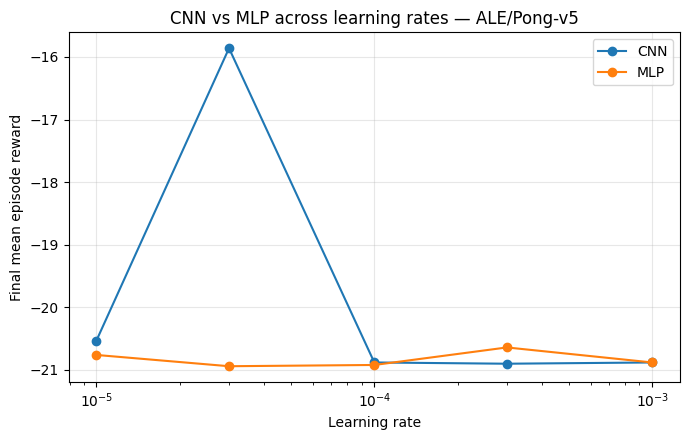

In [ ]:
import matplotlib.pyplot as plt

pivot = mine.pivot_table(index="lr", columns="policy", values="final_ep_rew_mean").sort_index()

fig, ax = plt.subplots(figsize=(7, 4.5))
for policy in pivot.columns:
    ax.plot(pivot.index, pivot[policy], marker="o", label=policy.upper())
ax.set_xscale("log")
ax.set_xlabel("Learning rate")
ax.set_ylabel("Final mean episode reward")
ax.set_title("CNN vs MLP across learning rates — ALE/Pong-v5")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, "lr_policy_comparison.png"), dpi=150)
plt.show()


## Slide-ready summary

Prints the numbers, not a written narrative — the narrative is mine to give live.

In [ ]:
best = mine.iloc[0]
cnn_mean = mine.loc[mine["policy"] == "cnn", "final_ep_rew_mean"].mean()
mlp_mean = mine.loc[mine["policy"] == "mlp", "final_ep_rew_mean"].mean()

print(f"Best config: {best['policy'].upper()} policy, lr={best['lr']}, reward={best['final_ep_rew_mean']:.2f}")
print(f"Average reward — CNN: {cnn_mean:.2f}, MLP: {mlp_mean:.2f}, gap: {cnn_mean - mlp_mean:.2f}")

for policy in ("cnn", "mlp"):
    sub = mine[mine["policy"] == policy].sort_values("lr")
    print(f"\n{policy.upper()} reward by learning rate:")
    for _, row in sub.iterrows():
        print(f"  lr={row['lr']:.0e}: reward={row['final_ep_rew_mean']:.2f}")


Best config: CNN policy, lr=3e-05, reward=-15.86
Average reward — CNN: -19.81, MLP: -20.83, gap: 1.02

CNN reward by learning rate:
  lr=1e-05: reward=-20.53
  lr=3e-05: reward=-15.86
  lr=1e-04: reward=-20.88
  lr=3e-04: reward=-20.90
  lr=1e-03: reward=-20.88

MLP reward by learning rate:
  lr=1e-05: reward=-20.76
  lr=3e-05: reward=-20.94
  lr=1e-04: reward=-20.92
  lr=3e-04: reward=-20.64
  lr=1e-03: reward=-20.88


## Push results back to the shared repo

Prompts for a personal access token at runtime — nothing is hardcoded or stored in the
notebook. The token is used once to set the remote URL, then stripped back out
afterward so it isn't left sitting in git config.

If `git pull --rebase` conflicts on `experiments_log.csv`, it's almost certainly two
people's appended rows landing in the same region — keep both sides' rows and drop the
conflict markers, then continue the rebase.

In [ ]:
from getpass import getpass

token = getpass("GitHub personal access token: ")
username = input("GitHub username: ")

%cd {REPO_DIR}
!git config user.email "{username}@users.noreply.github.com"
!git config user.name "{username}"

branch = !git rev-parse --abbrev-ref HEAD
branch = branch[0]

auth_url = REPO_URL.replace("https://", f"https://{username}:{token}@")
!git remote set-url origin {auth_url}

!git pull --rebase origin {branch}
!git add experiments_log.csv
!git commit -m "Add {MEMBER_NAME} lr/policy experiments"
!git push origin {branch}

# Strip the token back out of the remote URL now that the push is done
!git remote set-url origin {REPO_URL}
del token
